In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci, lo
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow
from detnqs.vstate import MCState
from detnqs.sampler import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [2]:
mol = gto.M(
    atom="; ".join([f"H 0 0 {i * 2.00}" for i in range(12)]),
    basis="sto-3g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Orthonormalized Atomic Orbitals (OAOs)
C = lo.orth.orth_ao(mol, 'lowdin')
h1e = C.T @ mf.get_hcore() @ C
eri = ao2mo.restore(8, ao2mo.kernel(mol, C), mol.nao_nr())
h1e[abs(h1e) < 1e-6] = eri[abs(eri) < 1e-6] = 0.0
mo_coeff = np.linalg.solve(C, mf.mo_coeff)

ref_mat = np.zeros((n_alpha + n_beta, 2 * norb))
ref_mat[:n_alpha, :norb] = mo_coeff[:, :n_alpha].T
ref_mat[n_alpha:, norb:] = mo_coeff[:, :n_beta].T

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

solver = fci.direct_spin0.FCI(mol)
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,), ref_mat=jnp.array(ref_mat))

SCF energy : -4.747583273791
FCI energy : -5.695805488911
S^2  : 0.000000


E0526 16:48:33.614989    2654 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0526 16:48:33.624563    2461 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [3]:
sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=1024,
    alpha=1.0,
    proposal="ham",
    blur=0.5,
    blur_kernel="ham",
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="random",
    key=jax.random.key(0),
)

optimizer = optax.chain(
    adamsr(shift=1e-3),
    optax.scale(-5e-2)
)

vmc = VMC.init(state, optimizer)

history = []
steps = 1000

for step in range(steps):
    stats = vmc.step()
    history.append(stats['energy'])

    if step % 10 == 0 or step == steps - 1:
        print(
            f"step={step:4d}  "
            f"energy={history[-1]: .8f}  "
            f"variance={stats['variance']: .8f}  "
            f"acc={stats['accept']:.3f}  "
            f"ess={stats['ess']: .1f}  "
            f"n_unique={stats['n_unique']: .3f}  "
            f"n_eval={stats['n_eval']:}"
        )

        time_items = sorted(
            (k[5:], float(stats[k])) for k in stats if k.startswith("time_")
        )
        if time_items:
            line = " | ".join(f"{name}= {val:.4f}" for name, val in time_items)
            print(f"         times: " + line)

step=   0  energy=-4.71737446  variance= 0.35173322  acc=0.777  ess= 439.9  n_unique= 1017.000  n_eval=52057.0
         times: backward= 0.6404 | forward= 0.4007 | graph= 0.0764 | optimizer= 5.4696 | reduce= 0.0052 | sample= 0.0087 | total= 6.6014
step=  10  energy=-5.17660135  variance= 0.15908402  acc=0.707  ess= 311.9  n_unique= 1016.000  n_eval=51616.0
         times: backward= 0.0091 | forward= 0.0929 | graph= 0.0482 | optimizer= 0.4382 | reduce= 0.0048 | sample= 0.0082 | total= 0.6018
step=  20  energy=-5.48374853  variance= 0.08949795  acc=0.592  ess= 148.0  n_unique= 1010.000  n_eval=50539.0
         times: backward= 0.0091 | forward= 0.0904 | graph= 0.0490 | optimizer= 0.4387 | reduce= 0.0047 | sample= 0.0082 | total= 0.6004
step=  30  energy=-5.61443027  variance= 0.03882199  acc=0.543  ess= 118.9  n_unique= 1015.000  n_eval=49315.0
         times: backward= 0.0103 | forward= 0.0936 | graph= 0.0473 | optimizer= 0.4334 | reduce= 0.0048 | sample= 0.0063 | total= 0.5962
step=  4

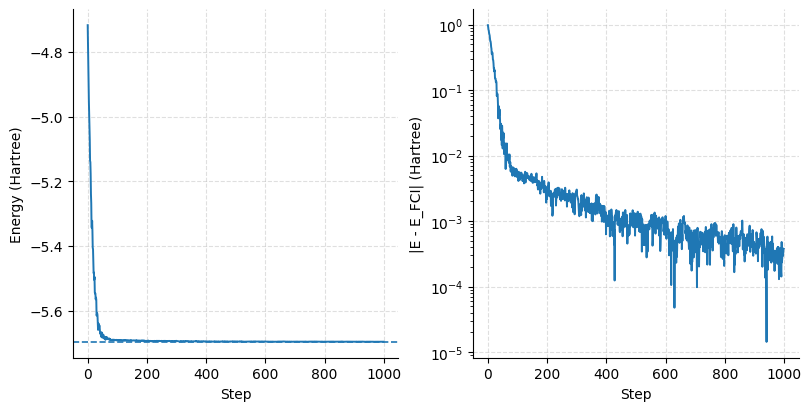

In [4]:
def plot_convergence(history, e_fci):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    step = np.arange(len(history))

    ax = axes[0]
    ax.plot(step, history, linewidth=1.4)
    ax.axhline(e_fci, linestyle="--", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Energy (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.semilogy(step, np.abs(np.asarray(history) - e_fci), linewidth=1.4)
    ax.set_xlabel("Step")
    ax.set_ylabel("|E - E_FCI| (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    return fig, axes

plot_convergence(history, e_fci)
plt.show()